### Student Name: Abdullah Junejo
### Student ID: 07154
### Student Email: aj07154@st.habib.edu.pk

### Goal

Another area where data science and machine learning play a huge role is in choosing if granting a loan. This is a particularly hot field as many start-ups feel that bank loan models can
be improved. Therefore, there is space to come up with better loan strategies that can benefit both the lender and the borrower.

In this challenge, you will have access to loan data from a bank and will have to improve their model.

### Datasets

The 2 datsets are:<br>
__Loan Data__ - general information about the Loan
Columns:
- loan_id : the id of the loan. Unique by loan. Can be joined to loan id in the other table
- loan_purpose : the reason for asking the loan: investment, business, emergency_funds, home, other,
- date : when the loan was asked
- loan_granted : whether the loan was granted
- loan_repaid : whether the loan was repaid. NA means that the loan was not granted

__Borrower Data__ - information about the borrower
Columns:
- loan_id : the id of the the loan. Unique by loan. Can be joined to loan id in the other table
- is_first_loan : did she ask for any other loans in her lifetime?
- fully_repaid_previous_loans : did she pay on time all of her previous loans? If this is the first loan, it is NA
- currently_repaying_other_loans : is she currently repaying any other loans? If this is the first| loan, it is NA
- total_credit_card_limit : total credit card monthly limit
- avg_percentage_credit_card_limit_used_last_year : on an average, how much did she use of her credit card limit in the previous 12 months. This number can be >1 since it is possible to go above the credit card limit
- saving_amount : total saving account balance when she asked for the loan
- checking_amount : total checking account balance when she asked for the loan
- is_employed : whether she is employed (1) or not (0)
- yearly salary : how much she earned in the previous year
- age: her age
- dependent_number : number of people she claims as dependent

### Challenge Description

This is a classification problem, means 
- Build a classificaiton model which can predict whether to grant loan or not to grant loan to any borrower. For simplicity, create a new __decision column (target column or class cloumn)__ in your dataframe by assuming that:

If loan is granted and is not repaid then -1 (loan decision was wrong and caused loss)<br>
If loan is granted and is get repaid then 1 (loan decision was right and counts towards gain)

**loan_granted** and **loan_repaid** are the two columns you need to use to create the above decision (target) column. **Make sure to drop these two columns (loan_granted and loan_repaid) after you create your decision column and when you are building/training your classification model** since you will be using target/class column instead of these two columns <br>

Means
- If you grant the loan and the it doesn't get repaid, you lose 1
- If you grant the loan and the it does get repaid, you gain 1

- Using the rules above, build a model and evaluate its performance in terms of accuracy or any other metrics you think is good.

- Describe the impact of the most important variables on the prediction. Also, focus on variables __is_employed__ and __fully_repaid_previous_loans__ and __dependent_number__ which gives some information about the borrower at the time of loan. How does this variable impact the model? Explain why?

#### Some advice on how to do well on the Final Exam Data Science challenge.

- I picked a problem where everything is not clearly defined on purpose. It gives you an opportunity to exercise your Data Science intuition and make some assumptions/design decisions.
- I will evaluate you on multiple metrics i.e.. not just accuracy. I would like to see your expertise in all stages of the data science workflow: <br>
1. **data wrangling (cleaning and manipulation)** <br>
2. **atleast 4-5 exploratory data analysis (EDA) and visualization. Use different EDA methods and visualization types** <br>
3. **model training and evaluation**
4. and **interpretation of insights and results**
- There is no single correct answer to the challenge. Simplify the problem if you feel stuck. Drop Null values if needed.

In [46]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn import tree
import seaborn as sns                       #visualisation
import matplotlib.pyplot as plt             #visualisation
import statsmodels.api as sm
from statsmodels.formula.api import ols
%matplotlib inline     
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [47]:
# Read datasets
loan_df = pd.read_csv('loan_data.csv', parse_dates=['date'])
borrower_df = pd.read_csv('borrower_data.csv')

In [48]:
#Use the following code to merge two datasets
df = borrower_df.merge(loan_df, how='outer', on='loan_id')

In [49]:
df.head()

,loan_id,is_first_loan,fully_repaid_previous_loans,currently_repaying_other_loans,total_credit_card_limit,avg_percentage_credit_card_limit_used_last_year,saving_amount,checking_amount,is_employed,yearly_salary,age,dependent_number,loan_purpose,date,loan_granted,loan_repaid
0,289774,1,NaN,NaN,8000,0.49,3285,1073,0,0,47,3,business,2012-01-31,0,NaN
1,482590,0,1.0,0.0,4500,1.03,636,5299,1,13500,33,1,investment,2012-11-02,0,NaN
2,135565,1,NaN,NaN,6900,0.82,2085,3422,1,24500,38,8,other,2012-07-16,1,1.0
3,207797,0,1.0,0.0,1200,0.82,358,3388,0,0,24,1,investment,2012-06-05,0,NaN
4,828078,0,0.0,0.0,6900,0.80,2138,4282,1,18100,36,1,emergency_funds,2012-11-28,0,NaN


## Data Cleaning/Wrangling


In [50]:
df.isnull().sum()

loan_id                                                0
is_first_loan                                          0
fully_repaid_previous_loans                        54947
currently_repaying_other_loans                     54947
total_credit_card_limit                                0
avg_percentage_credit_card_limit_used_last_year     6972
saving_amount                                          0
checking_amount                                        0
is_employed                                            0
yearly_salary                                          0
age                                                    0
dependent_number                                       0
loan_purpose                                           0
date                                                   0
loan_granted                                           0
loan_repaid                                        53446
dtype: int64

In [51]:
#Creates a status column based on 'loan_granted' or 'loan_repaid'
df['status'] = df.apply(lambda row: 1 if row['loan_granted'] == 1 and row['loan_repaid'] == 1 else 
                          -1 if row['loan_granted'] == 1 and row['loan_repaid'] == 0 else 
                          0, axis=1)

#Droping old ones
df.drop(['loan_granted', 'loan_repaid'], axis=1, inplace=True)

#fill with -1 for first-time borrowers as they have na. So we will initialize it with something such as -1. Not using 0 as that would imply something entirely else.
df['fully_repaid_previous_loans'].fillna(-1, inplace=True)
df['currently_repaying_other_loans'].fillna(-1, inplace=True)

#Filling with the median as its best for data with outliers
median_credit_usage = df['avg_percentage_credit_card_limit_used_last_year'].median()
df['avg_percentage_credit_card_limit_used_last_year'].fillna(median_credit_usage, inplace=True)

#One-hot encoding for 'loan_purpose'
df = pd.get_dummies(df, columns=['loan_purpose'], drop_first=True) #its categorical. Hence, its values can be effectively used by machine learning algorithms.

df.head()

,loan_id,is_first_loan,fully_repaid_previous_loans,currently_repaying_other_loans,total_credit_card_limit,avg_percentage_credit_card_limit_used_last_year,saving_amount,checking_amount,is_employed,yearly_salary,age,dependent_number,date,status,loan_purpose_emergency_funds,loan_purpose_home,loan_purpose_investment,loan_purpose_other
0,289774,1,-1.0,-1.0,8000,0.49,3285,1073,0,0,47,3,2012-01-31,0,0,0,0,0
1,482590,0,1.0,0.0,4500,1.03,636,5299,1,13500,33,1,2012-11-02,0,0,0,1,0
2,135565,1,-1.0,-1.0,6900,0.82,2085,3422,1,24500,38,8,2012-07-16,1,0,0,0,1
3,207797,0,1.0,0.0,1200,0.82,358,3388,0,0,24,1,2012-06-05,0,0,0,1,0
4,828078,0,0.0,0.0,6900,0.80,2138,4282,1,18100,36,1,2012-11-28,0,1,0,0,0


In [52]:
df.isnull().sum()

loan_id                                            0
is_first_loan                                      0
fully_repaid_previous_loans                        0
currently_repaying_other_loans                     0
total_credit_card_limit                            0
avg_percentage_credit_card_limit_used_last_year    0
saving_amount                                      0
checking_amount                                    0
is_employed                                        0
yearly_salary                                      0
age                                                0
dependent_number                                   0
date                                               0
status                                             0
loan_purpose_emergency_funds                       0
loan_purpose_home                                  0
loan_purpose_investment                            0
loan_purpose_other                                 0
dtype: int64

In [53]:
#All are zero now. Data has been Cleaned.

## Data Visualization


### I will be using 4 Visualizatiosn

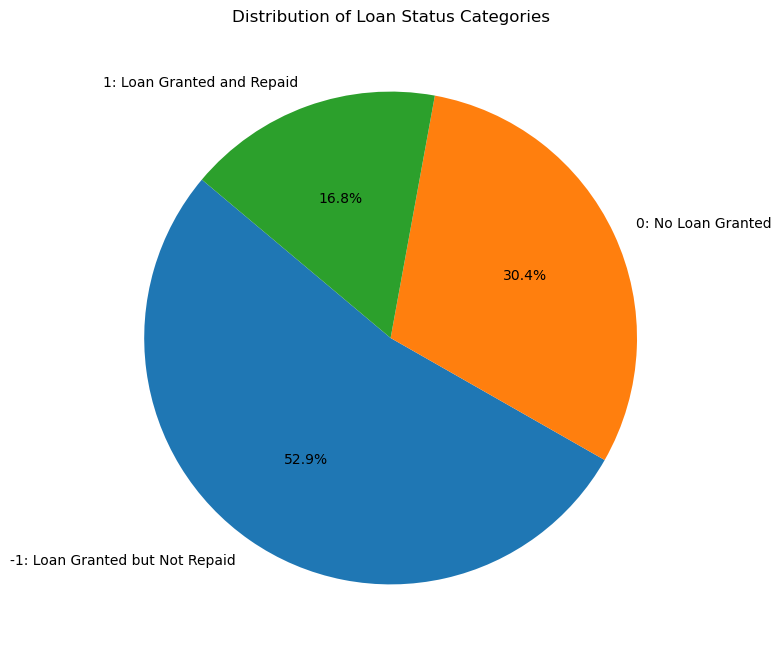

In [54]:
plt.figure(figsize=(8, 8))
df['status'].value_counts().plot(kind='pie', autopct='%1.1f%%',labels=['-1: Loan Granted but Not Repaid', '0: No Loan Granted', '1: Loan Granted and Repaid'], startangle=140)
plt.title('Distribution of Loan Status Categories')
plt.ylabel('')  # Hide the y-label
plt.show()

### Looks like High percentage of Loans granted but nto paaid implies that the bank is selecting bad customers who fail to pay back on time or most of its customers are new. There is small number of customers that have No Loan. Which means majority of customers are not financially well of. Small percentage of people (green) have good repaying.

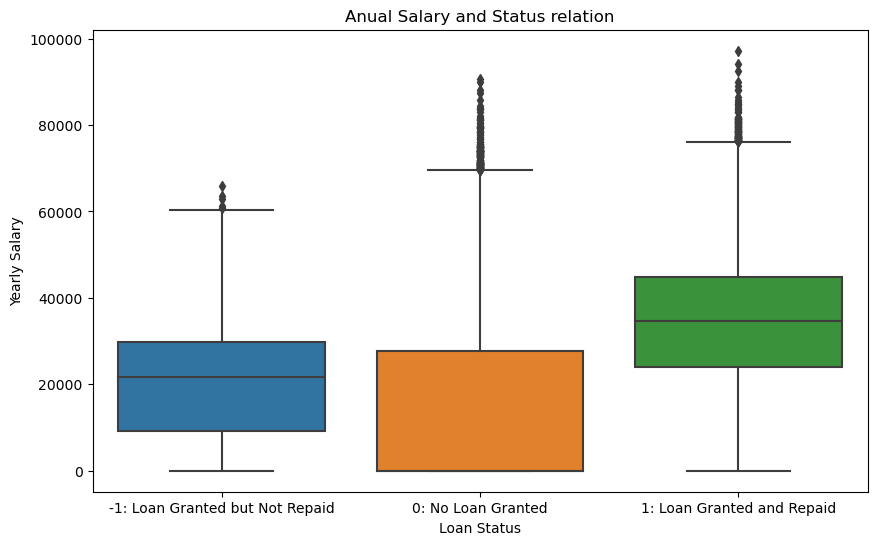

In [55]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='status', y='yearly_salary', data=df)
plt.xticks([0, 1, 2], ['-1: Loan Granted but Not Repaid', '0: No Loan Granted', '1: Loan Granted and Repaid'])  # Set the custom labels

plt.title('Anual Salary and Status relation')
plt.xlabel('Loan Status')
plt.ylabel('Yearly Salary')

plt.show()

### Looks like My initial assumption in pie chart was wrong. Status 0 has almost the same salary as -1 which means the orange sector is not financially well of relative to status -1. However, the repayers (green) are indeed financially better. This means that bank needs to better target the orange customers by providing incentives or some sort of campaigns. One more important thing to note would be outliers (The 60thousand-nier (not millionaire) category. They earn near the upper limit of the entire customer population.

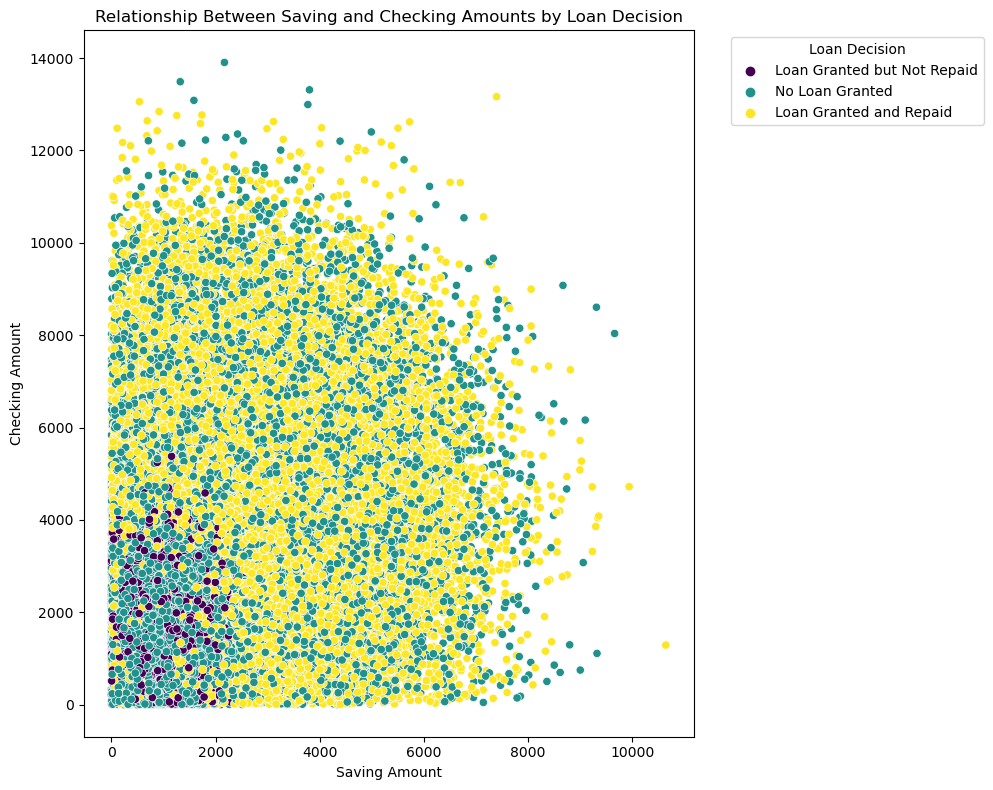

In [56]:
plt.figure(figsize=(12, 8))
scatter_plot = sns.scatterplot(
    x='saving_amount', 
    y='checking_amount', 
    hue='status', 
    data=df,
    palette='viridis'
)

decision_labels = {
    -1: 'Loan Granted but Not Repaid',
    0: 'No Loan Granted',
    1: 'Loan Granted and Repaid'
}

unique_decisions = df['status'].unique()
handles, labels = scatter_plot.get_legend_handles_labels()
new_labels = [decision_labels[int(label)] for label in labels]

scatter_plot.legend(
    handles=handles, 
    labels=new_labels,
    title='Loan Decision',
    bbox_to_anchor=(1.05, 1), #Place the legend outside the plot area
    loc='upper left'
)

plt.title('Relationship Between Saving and Checking Amounts by Loan Decision')
plt.xlabel('Saving Amount')
plt.ylabel('Checking Amount')

#Adjust the plot to make room for the legend
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

### Logically it makes sense that No Loan People (Dark Green) are almost everywhere. Same goes for repayers. However the difference comes into play when we talk about granted but not repaid (purple). This shows that bank intelligently offered loans to lowest checking and saving amount people. This could be bad as these people can default.

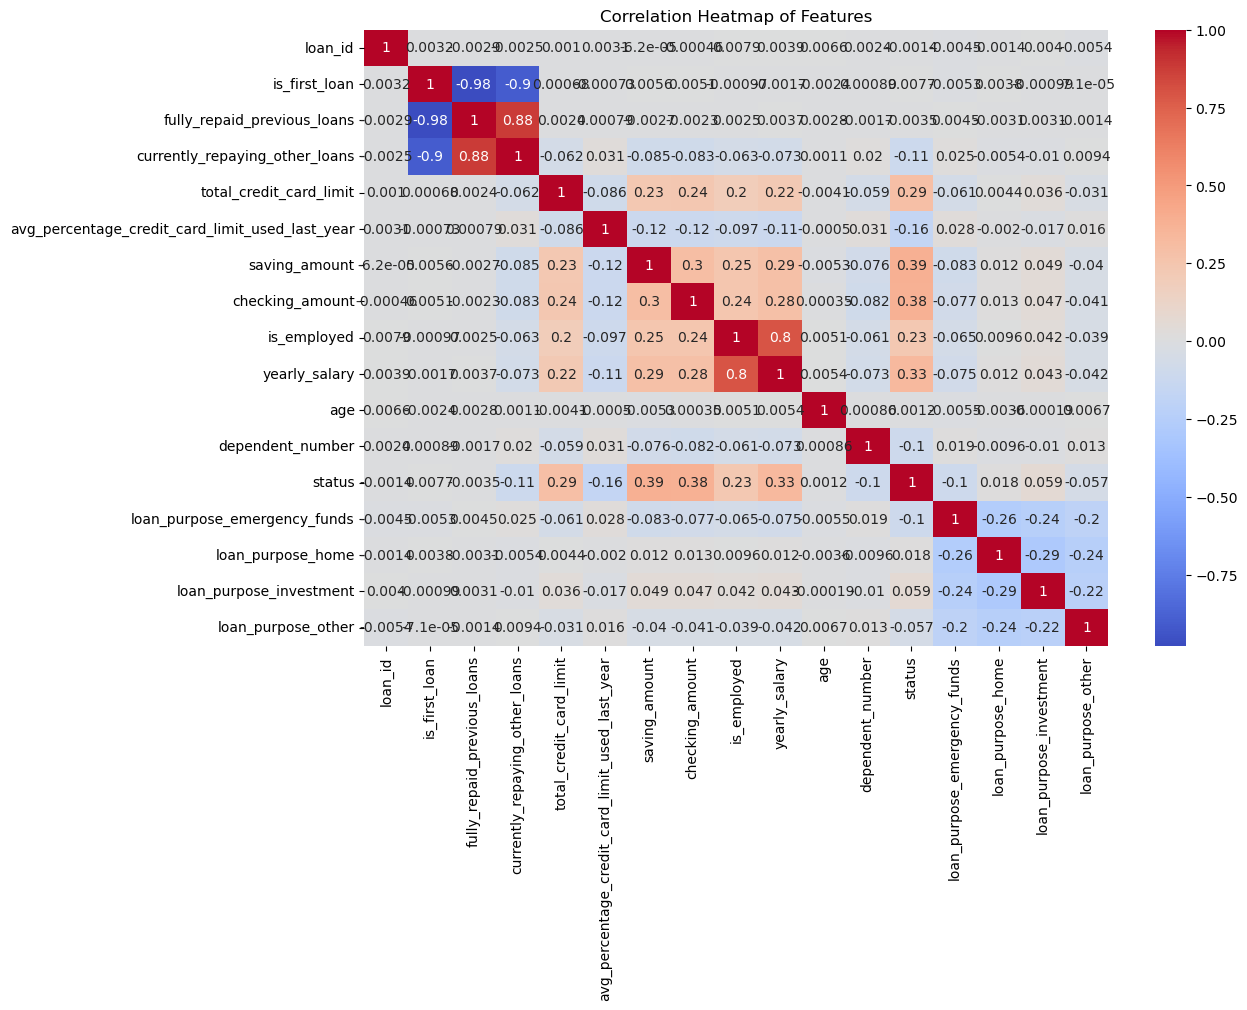

In [57]:
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Features')
plt.show()

### is_first_loan, fully_repaid_previous_loans, and currently_repaying_other_loans have negative correlation since they do not happen at the same time (Mutually Exclusive). Also, strong positive correlation (0.80) between is_employed and yearly_salary which is quite natural to assume as well. An interesting mild corelation would be that higher credit limit and salary. All in all, these show that our dataset is quite reliable as the corelations are true to actual stereotypes/norms.

## Model Training.

In [81]:
dataf = df.drop('date', axis=1, inplace=False)

X = dataf.drop('status', axis=1)
Y = dataf['status']

X = sm.add_constant(X)

model = sm.OLS(Y, X).fit()

model_summary = model.summary()
print(model_summary)


                            OLS Regression Results                            
Dep. Variable:                 status   R-squared:                       0.302
Model:                            OLS   Adj. R-squared:                  0.302
Method:                 Least Squares   F-statistic:                     2740.
Date:                Wed, 13 Dec 2023   Prob (F-statistic):               0.00
Time:                        10:24:04   Log-Likelihood:                -85197.
No. Observations:              101100   AIC:                         1.704e+05
Df Residuals:                  101083   BIC:                         1.706e+05
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                                                      coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------

### Few Insights: is_first_loan has a negative coefficient, which implies first-time borrowers are less likely to have their loans granted.


In [82]:
decision_tree_model = tree.DecisionTreeClassifier(random_state=0)

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=0)

decision_tree_model = decision_tree_model.fit(X_train, y_train)

train_predictions = decision_tree_model.predict(X_train)

training_accuracy = accuracy_score(train_predictions, y_train)
print('Training data Accuracy:', training_accuracy)


Training data Accuracy: 1.0


### This shows that Data is perfect enough

In [84]:
test_prediction = decision_tree_model.predict(X_test)
accuracy = accuracy_score(test_prediction, y_test)
print('Accuracy on test data:', accuracy)
accuracy*100

Accuracy on test data: 0.6228156940323113


62.28156940323113

### Looks like the model is not the best fit here.

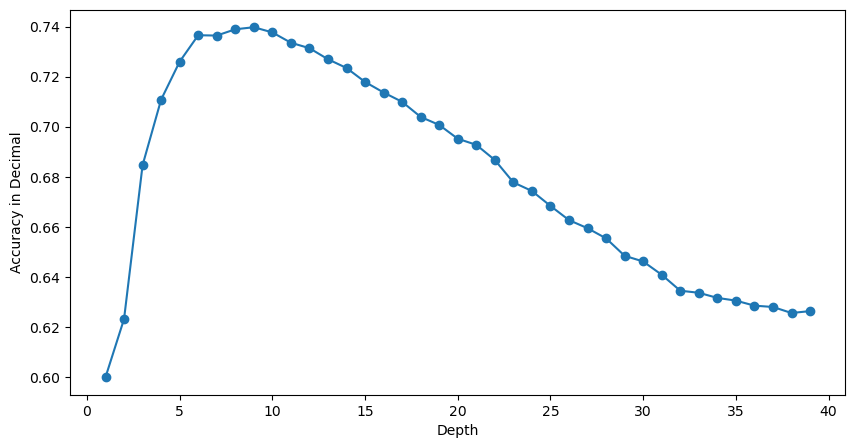

In [87]:
max_depth,acc_gini = [], []
for i in range(1,40):
    decision_tree_model = tree.DecisionTreeClassifier(criterion='gini', max_depth=i, random_state=99)
    decision_tree_model.fit(X_train, y_train)
    pred = decision_tree_model.predict(X_test)
    acc_gini.append(accuracy_score(y_test, pred))
    max_depth.append(i)

d = pd.DataFrame({'acc_gini':pd.Series(acc_gini), 'max_depth':pd.Series(max_depth)})
plt.figure(figsize=(10,5))
plt.plot('max_depth', 'acc_gini', data=d, marker='o')
plt.xlabel('Depth')
plt.ylabel('Accuracy in Decimal')
plt.show()

### Looks like we need to reduce the depth for maximum Accuracy

In [92]:
decision_tree_model = tree.DecisionTreeClassifier(criterion='gini', max_depth=10, random_state=99)
decision_tree_model = decision_tree_model.fit(X_train, y_train)
train_prediction = decision_tree_model.predict(X_train)
accuracy = accuracy_score(train_prediction, y_train)
print('Accuracy training data:', accuracy)
accuracy*100

Accuracy training data: 0.7443125618199802


74.43125618199802

In [93]:
test_prediction = decision_tree_model.predict(X_test)
accuracy = accuracy_score(test_prediction, y_test)
print('Accuracy on test data:', accuracy)
accuracy*100

Accuracy on test data: 0.7376524892845367


73.76524892845367

### Our accuracy has increased!

### Couldn't write analysis. Time ended